# TUGAS BESAR: Komparasi Model Ensemble Learning (Random Forest vs XGBoost) dalam Prediksi Pergerakan Harga Saham BBCA

**Deskripsi Proyek:**
Proyek ini bertujuan untuk membangun dan membandingkan dua arsitektur *Machine Learning* berbasis pohon keputusan (Tree-Based Models): **Random Forest (Bagging)** dan **XGBoost (Boosting)**. Model ini dirancang untuk memprediksi probabilitas arah pergerakan harga saham PT Bank Central Asia Tbk (BBCA) dalam jendela waktu ( *holding period* ) 5 hari ke depan. 

Analisis ini juga mengimplementasikan evaluasi *Walk-Forward Backtesting* dan menyertakan metrik finansial riil seperti biaya transaksi broker serta analisis dampak makroekonomi (Kurs USD/IDR).

## 1. Inisialisasi Lingkungan Kerja dan Import Pustaka
Tahap pertama adalah memuat pustaka ( *libraries* ) standar industri yang dibutuhkan untuk manipulasi data, pemodelan statistik, dan visualisasi.
- `pandas` & `numpy`: Manipulasi struktur data *Time-Series*.
- `scikit-learn` & `xgboost`: Implementasi algoritma *Machine Learning* dan metrik evaluasi.
- `yfinance`: Ekstraksi data makroekonomi eksogen secara *real-time*.
- `matplotlib` & `seaborn`: Representasi grafis dari kinerja model.

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
import yfinance as yf

# Mengatur tema visualisasi
sns.set_theme(style="whitegrid")

## 2. Ekstraksi dan Pembersihan Data (Data Preprocessing)
Dataset historis saham BBCA dimuat ke dalam *DataFrame*. Proses prapemrosesan meliputi standardisasi penamaan kolom, konversi indeks waktu ( *DatetimeIndex* ), dan eliminasi fitur yang redundan guna mengurangi dimensionalitas data yang tidak relevan.

In [150]:
bbca = pd.read_csv('BBCA.JK.csv', parse_dates=['Date'], index_col='Date')
bbca.rename(columns={"open": "Open", "high": "High", "low": "Low", "close": "Close", "volume": "Volume"}, inplace=True)
bbca = bbca.drop(columns=['adjclose', 'ingested_at_utc'], errors='ignore')

## 3. Formulasi Variabel Target (Target Variable Definition)
Pendekatan pemodelan diubah dari regresi menjadi **Klasifikasi Biner (Binary Classification)**. 
Target prediksi (`Target_5D`) bernilai `1` jika harga penutupan 5 hari ke depan lebih besar dari harga pembukaan hari berikutnya, dan `0` jika sebaliknya. Hal ini memodelkan skenario *Swing Trading* guna meminimalisir eksposur risiko harian pasar.

In [151]:
bbca["Tomorrow_Open"] = bbca["Open"].shift(-1)
bbca["Close_5_Days"] = bbca["Close"].shift(-5)
bbca["Target_5D"] = (bbca["Close_5_Days"] > bbca["Tomorrow_Open"]).astype(int)
bbca["Trade_Return_5D"] = (bbca["Close_5_Days"] / bbca["Tomorrow_Open"]) - 1    

## 4. Rekayasa Fitur (Feature Engineering): Indikator Teknikal
Penambahan indikator teknikal untuk menangkap pola momentum dan tren harga historis:
1. **Simple Moving Average (SMA)**: SMA 50-hari dan SMA 200-hari digunakan untuk mendeteksi rezim pasar ( *Bullish/Bearish* ).
2. **Relative Strength Index (RSI 14)**: Indikator momentum osilator untuk mendeteksi kondisi *Overbought* (jenuh beli) atau *Oversold* (jenuh jual).

In [152]:
bbca["MA50"] = bbca["Close"].rolling(50).mean()
bbca["MA200"] = bbca["Close"].rolling(200).mean()
bbca["MA_Trend"] = (bbca["MA50"] > bbca["MA200"]).astype(int)
bbca["Cross_Signal"] = bbca["MA_Trend"].diff()

delta = bbca["Close"].diff()
up = delta.clip(lower=0)
down = -1 * delta.clip(upper=0)
ema_up = up.ewm(com=13, adjust=False).mean()
ema_down = down.ewm(com=13, adjust=False).mean()
rs = ema_up / ema_down
bbca["RSI_14"] = 100 - (100 / (1 + rs))

bbca["Target_1D_History"] = (bbca["Close"].shift(-1) > bbca["Open"].shift(-1)).astype(int)

## 5. Ekstraksi Pola Multi-Horizon (Rolling Window Features)
Ekstraksi fitur statis seringkali tidak cukup untuk menangkap volatilitas. Fitur `Close_Ratio` (perbandingan harga saat ini dengan nilai rerata historis) dan fitur `Trend` (kalkulasi deret kemenangan historis) diturunkan dalam beberapa jendela waktu (*horizons*): 2, 5, 60, dan 250 hari perdagangan. 

In [153]:
horizons = [2, 5, 60, 250]
predictors = ["MA50", "MA200", "MA_Trend", "Cross_Signal", "RSI_14"]

for horizon in horizons:
    rolling_averages = bbca["Close"].rolling(horizon).mean()
    ratio_column = f"Close_Ratio_{horizon}"
    bbca[ratio_column] = bbca["Close"] / rolling_averages

    trend_column = f"Trend_{horizon}" 
    bbca[trend_column] = bbca["Target_1D_History"].shift(1).rolling(horizon).sum()
    predictors += [ratio_column, trend_column]

# Menghapus baris yang mengandung Nilai Kosong (NaN) akibat proses rolling window
bbca = bbca.dropna().copy()

## 6. Arsitektur Pemodelan: Inisialisasi Algoritma
Dua algoritma *Ensemble Learning* digunakan sebagai subjek evaluasi komparatif:
1. **Random Forest Classifier**: Menggunakan teknik *Bagging* (Bootstrap Aggregating) untuk mereduksi *variance* dan mencegah *overfitting*.
2. **XGBoost Classifier**: Menggunakan teknik *Gradient Boosting*, di mana model sekuensial dilatih untuk meminimalisasi *loss function* (LogLoss) dari model sebelumnya. Regularisasi ketat diterapkan melalui `learning_rate` rendah (0.01) dan batas `max_depth` (3).

In [154]:
model_rf = RandomForestClassifier(
    n_estimators=10100, 
    min_samples_split=100, 
    random_state=1
)

model_xgb = XGBClassifier(
    n_estimators=1000, 
    learning_rate=0.005, 
    max_depth=3, 
    subsample=0.7,
    colsample_bytree=0.7,
    random_state=1, 
    eval_metric='logloss',
    reg_alpha=10,    # Menghapus fitur yang kurang penting secara agresif
    reg_lambda=5,    # Memperhalus bobot prediksi pohon
)

## 7. Metodologi Validasi: Walk-Forward Backtesting
Mengingat sifat data deret waktu finansial yang non-stasioner, validasi K-Fold konvensional dilarang untuk menghindari *Future Data Leakage*. 

Kami merancang fungsi `backtest()` berbasis **Walk-Forward Validation**. Model dilatih pada data historis awal (500 observasi), kemudian memprediksi blok data berikutnya (250 observasi). Jendela waktu kemudian bergeser maju, mereplikasi kondisi perdagangan riil. Ambang batas probabilitas ( *threshold* ) ditetapkan secara konservatif pada **0.65** (65%) untuk mengeksekusi kelas positif ( *Buy Signal* ).

In [155]:
def predict(train, test, predictors, model):
    if "XGB" in type(model).__name__:
        model.fit(
            train[predictors], 
            train["Target_5D"], 
            eval_set=[(test[predictors], test["Target_5D"])],
            verbose=False # Agar tidak membanjiri layar dengan teks log setiap pohon
        )
    else:
        model.fit(train[predictors], train["Target_5D"])
    preds = model.predict_proba(test[predictors])[:,1]
    
    # Penerapan Threshold Konservatif
    preds[preds >= 0.7] = 1
    preds[preds < 0.7] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target_5D"], preds, test["Trade_Return_5D"]], axis=1)
    return combined

def backtest(data, model, predictors, start=500, step=250):
    all_predictions = []
    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i + step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)
    return pd.concat(all_predictions)

## 8. Eksekusi Model Dasar (Baseline Execution)
Tahap ini mengeksekusi fungsi pelatihan dan pengujian historis untuk kedua arsitektur model menggunakan serangkaian fitur teknikal intrinsik saham.

In [156]:
print("Mengeksekusi Backtest Algoritma Random Forest...")
preds_rf = backtest(bbca, model_rf, predictors)

print("Mengeksekusi Backtest Algoritma XGBoost...")
preds_xgb = backtest(bbca, model_xgb, predictors)
print("Selesai.")

Mengeksekusi Backtest Algoritma Random Forest...
Mengeksekusi Backtest Algoritma XGBoost...
Selesai.


## 9. Evaluasi Finansial dan Return Kumulatif
Evaluasi kinerja tidak hanya ditinjau dari akurasi klasifikasi, melainkan dari profibilitas portofolio berbobot-waktu. 
Variabel `FEE_TRANSAKSI` sebesar 0.4% (0.004) diperkenalkan untuk mencerminkan biaya komisi broker dua arah (Beli-Jual), menciptakan lingkungan simulasi finansial yang presisi.

In [157]:
FEE_TRANSAKSI = 0.004 

# Kalkulasi Pertumbuhan Portofolio: Random Forest
preds_rf["Strategy_Return_Net"] = preds_rf["Predictions"] * (preds_rf["Trade_Return_5D"] - FEE_TRANSAKSI)
preds_rf["Cumulative_Net"] = (1 + preds_rf["Strategy_Return_Net"]).cumprod()

# Kalkulasi Pertumbuhan Portofolio: XGBoost
preds_xgb["Strategy_Return_Net"] = preds_xgb["Predictions"] * (preds_xgb["Trade_Return_5D"] - FEE_TRANSAKSI)
preds_xgb["Cumulative_Net"] = (1 + preds_xgb["Strategy_Return_Net"]).cumprod()

# Kalkulasi Portofolio Pasif (Benchmark: Buy and Hold)
market_cumulative = (1 + preds_xgb["Trade_Return_5D"]).cumprod()

## 10. Iterasi Lanjutan: Penambahan Variabel Makroekonomi (USD/IDR)
Pergerakan indeks saham perbankan kapitalisasi besar (seperti BBCA) sangat berkorelasi dengan aliran dana asing dan stabilitas nilai tukar valuta asing. 
Oleh karena itu, variabel eksogen berupa Nilai Tukar USD/IDR serta persentase perubahan momentum USD dalam 5-hari diintegrasikan ke dalam matriks *predictors*.

In [158]:
print("Mengunduh data eksternal Makroekonomi (USD/IDR)...")
usdidr = yf.Ticker("IDR=X").history(start="2019-01-01")
kurs = usdidr[['Close']].rename(columns={'Close': 'USD_IDR'})
kurs.index = kurs.index.tz_localize(None)

bbca = bbca.join(kurs, how="left")
bbca["USD_IDR"] = bbca["USD_IDR"].ffill() # Forward-fill untuk interpolasi nilai libur pasar valas
bbca["USD_Trend_5D"] = bbca["USD_IDR"].pct_change(periods=5)

predictors_makro = predictors + ["USD_IDR", "USD_Trend_5D"]
bbca = bbca.dropna().copy()

print("Mengeksekusi Backtest Ulang Random Forest (+Variabel Makro)...")
preds_rf_makro = backtest(bbca, model_rf, predictors_makro)

print("Mengeksekusi Backtest Ulang XGBoost (+Variabel Makro)...")
preds_xgb_makro = backtest(bbca, model_xgb, predictors_makro)

# Kalkulasi ulang return finansial untuk model dengan variabel makro
preds_rf_makro["Strategy_Return_Net"] = preds_rf_makro["Predictions"] * (preds_rf_makro["Trade_Return_5D"] - FEE_TRANSAKSI)
preds_rf_makro["Cumulative_Net"] = (1 + preds_rf_makro["Strategy_Return_Net"]).cumprod()

preds_xgb_makro["Strategy_Return_Net"] = preds_xgb_makro["Predictions"] * (preds_xgb_makro["Trade_Return_5D"] - FEE_TRANSAKSI)
preds_xgb_makro["Cumulative_Net"] = (1 + preds_xgb_makro["Strategy_Return_Net"]).cumprod()

market_cumulative_makro = (1 + preds_xgb_makro["Trade_Return_5D"]).cumprod()

Mengunduh data eksternal Makroekonomi (USD/IDR)...
Mengeksekusi Backtest Ulang Random Forest (+Variabel Makro)...
Mengeksekusi Backtest Ulang XGBoost (+Variabel Makro)...


## 11. Hasil Analisis dan Visualisasi
Representasi grafis dari perbandingan ekuitas kumulatif antara strategi model *Machine Learning* berlandaskan fitur hibrida (Teknikal + Makro) terhadap *benchmark* pergerakan pasar ( *Buy & Hold* ).

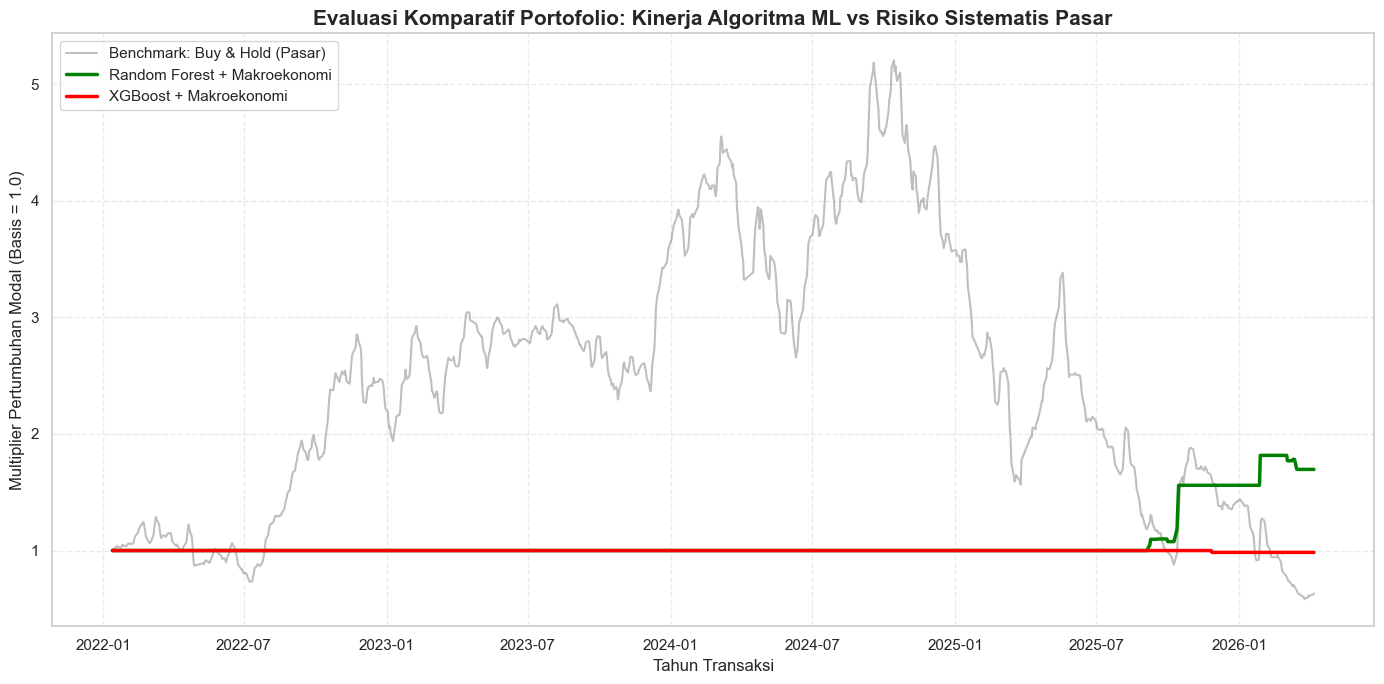

In [159]:
plt.figure(figsize=(14, 7))
plt.plot(preds_xgb_makro.index, market_cumulative_makro, label="Benchmark: Buy & Hold (Pasar)", color="gray", alpha=0.5, linewidth=1.5)
plt.plot(preds_rf_makro.index, preds_rf_makro["Cumulative_Net"], label="Random Forest + Makroekonomi", color="green", linewidth=2.5)
plt.plot(preds_xgb_makro.index, preds_xgb_makro["Cumulative_Net"], label="XGBoost + Makroekonomi", color="red", linewidth=2.5)

plt.title("Evaluasi Komparatif Portofolio: Kinerja Algoritma ML vs Risiko Sistematis Pasar", fontsize=15, fontweight='bold')
plt.xlabel("Tahun Transaksi", fontsize=12)
plt.ylabel("Multiplier Pertumbuhan Modal (Basis = 1.0)", fontsize=12)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

## 12. Kesimpulan Evaluasi Kinerja (Performance Report)
Metrik evaluasi utama dalam sistem perdagangan prediktif ini menggunakan fungsi `precision_score`, yang menilai persentase akurasi model ketika memancarkan sinyal positif (Tingkat Kepastian *True Positive*). Metrik finansial utama dinilai dari nilai Net Profit.

In [160]:
def generate_report(preds_df, model_name):
    presisi = precision_score(preds_df["Target_5D"], preds_df["Predictions"]) * 100
    jumlah_trade = preds_df['Predictions'].sum()
    total_net = (preds_df["Cumulative_Net"].iloc[-1] - 1) * 100
    print(f"[{model_name} PERFORMANCE METRICS]")
    print(f"Tingkat Presisi (Positive Predictive Value) : {presisi:.2f}%")
    print(f"Frekuensi Eksekusi Transaksi              : {jumlah_trade} Posisi")
    print(f"Total Cumulative Return (Net Profit)      : {total_net:.2f}%\n")

total_market = (market_cumulative_makro.iloc[-1] - 1) * 100
print("="*60)
print(f"BENCHMARK PASAR BBCA (BUY & HOLD STRATEGY)")
print(f"Systematic Risk Return: {total_market:.2f}%")
print("="*60, "\n")

generate_report(preds_rf_makro, "RANDOM FOREST (TEKNIKAL + MAKRO)")
generate_report(preds_xgb_makro, "XGBOOST (TEKNIKAL + MAKRO)")

BENCHMARK PASAR BBCA (BUY & HOLD STRATEGY)
Systematic Risk Return: -36.77%

[RANDOM FOREST (TEKNIKAL + MAKRO) PERFORMANCE METRICS]
Tingkat Presisi (Positive Predictive Value) : 75.00%
Frekuensi Eksekusi Transaksi              : 12.0 Posisi
Total Cumulative Return (Net Profit)      : 69.62%

[XGBOOST (TEKNIKAL + MAKRO) PERFORMANCE METRICS]
Tingkat Presisi (Positive Predictive Value) : 0.00%
Frekuensi Eksekusi Transaksi              : 1.0 Posisi
Total Cumulative Return (Net Profit)      : -1.60%

